In [1]:
import atomic_units as au

abu = au.AtomicBaseUnits()
print(abu)

#abu2 = au.AtomicBaseUnits(1.0, 1.0, 1.0, 2.0)
#print(abu2)

Unit and value of atomic base units in this rescaled atomic units:
- action unit := 	1.0545718176461565e-34 kilogram * meter ** 2 / second
- modified planck constant hbar := 	1.0
- charge unit := 	1.602176634e-19 coulomb
- elementary charge e0:= 	1.0
- mass unit := 	9.1093837015e-31 kilogram
- electron mass me := 	1.0
- modified permittivity unit := 	1.1126500554434379e-10 farad / meter
- modified permittivity kappa0 := 	1.0



In [2]:
import atomic_units as au
import pint

ureg = pint.UnitRegistry()
print(ureg("hbar").to_base_units())
print(ureg("vacuum_permittivity").to("F/m"))
print(ureg("speed_of_light").to("m/s"))

atomic_units_system = au.AtomicUnitSystem(base_units=abu)
print(atomic_units_system)
print(atomic_units_system.energy_unit.to(ureg.eV))

print(f"Length unit in SI: {atomic_units_system.length_unit.to(ureg.m)}")
print(f"Length unit in AU: {atomic_units_system.length_unit.to(ureg.bohr)}")

1.0545718176461565e-34 kilogram * meter ** 2 / second
8.854187812764727e-12 farad / meter
299792458.0 meter / second
Unit and value of atomic base units in this rescaled atomic units:
- action unit := 	1.0545718176461565e-34 kilogram * meter ** 2 / second
- modified planck constant hbar := 	1.0
- charge unit := 	1.602176634e-19 coulomb
- elementary charge e0:= 	1.0
- mass unit := 	9.1093837015e-31 kilogram
- electron mass me := 	1.0
- modified permittivity unit := 	1.1126500554434379e-10 farad / meter
- modified permittivity kappa0 := 	1.0

Unit and value of atomic units in this rescaled atomic units:
- length unit := 	5.291772109039774e-11 meter
- energy unit := 	4.35974472220717e-18 joule
- time unit := 	2.4188843265856803e-17 second
- frequency unit := 	4.134137333518245e+16 hertz
- velocity unit := 	2187691.263645191 meter / second
- speed of light := 	137.03599908356244
- electric field unit := 	514220674762.318 volt / meter
- electric potential unit := 	27.21138624598847 volt

27

In [3]:
import atomic_units as au
import pint
import numpy as np

hb=0.1
e0=10.0
m0=10.0
kappa0=1000.0 # 4*pi*epsilon0
dx=0.025

print(1.0/(2*dx**2))
print(e0**2/(kappa0*hb))

prefactor = hb**2/(2*m0*dx**2)
desired_prefactor = 0.5
prefactor_error = np.abs(prefactor-desired_prefactor)/desired_prefactor
print(f"Prefactor: {prefactor}")
print(f"Prefactor error: {prefactor_error}")

ureg = pint.UnitRegistry()

length_unit = ((kappa0 * hb ** 2 / (m0 * e0 ** 2))*ureg.bohr).to('nm')
step_unit = dx*length_unit
desired_step_unit = 0.1*ureg.nm
step_unit_error = (np.abs(step_unit-desired_step_unit)/desired_step_unit).magnitude
print(f"step unit in SI: {step_unit.to('nm')}")
print(f"step unit error: {step_unit_error}")

scaled_units_system = au.AtomicUnitSystem(hb=hb, e0=e0, me=m0, k0=kappa0)

print(scaled_units_system)
print(scaled_units_system.mass_unit.to('kg'))

print(f"Length unit: {scaled_units_system.length_unit.to('nm')}")
print(f"Step unit: {dx*scaled_units_system.length_unit.to('nm')}")
print(f"Length unit in AU: {scaled_units_system.length_unit.to('bohr')}")


799.9999999999999
1.0
Prefactor: 0.8
Prefactor error: 0.6000000000000001
step unit in SI: 1.322943027259944e-05 nanometer
step unit error: 0.999867705697274
Unit and value of atomic base units in this rescaled atomic units:
- action unit := 	1.0545718176461564e-33 kilogram * meter ** 2 / second
- modified planck constant hbar := 	0.1
- charge unit := 	1.602176634e-20 coulomb
- elementary charge e0:= 	10.0
- mass unit := 	9.109383701500001e-32 kilogram
- electron mass me := 	10.0
- modified permittivity unit := 	1.112650055443438e-13 farad / meter
- modified permittivity kappa0 := 	1000.0

Unit and value of atomic units in this rescaled atomic units:
- length unit := 	5.291772109039772e-09 meter
- energy unit := 	4.359744722207174e-19 joule
- time unit := 	2.418884326585678e-15 second
- frequency unit := 	413413733351824.94 hertz
- velocity unit := 	2187691.263645192 meter / second
- speed of light := 	137.0359990835624
- electric field unit := 	5142206747.623186 volt / meter
- electric

# testing masking functions

0.20202020202020243


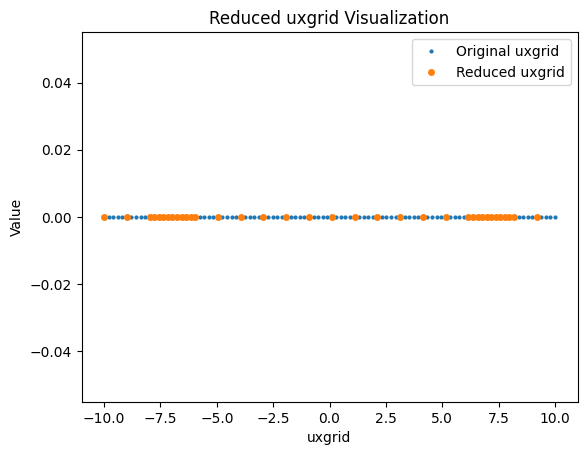

In [4]:
import numpy as np
import matplotlib.pyplot as plt

uxgrid_num = 100
uxgrid = np.linspace(-10, 10, uxgrid_num)
uxgrid_dx = uxgrid[1]-uxgrid[0]
print(uxgrid_dx)

# Desired number of points
desired_points = 20

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Highlighted ranges
highlight_ranges = [(-8, -6), (6, 8)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

mask += mask_highlight_ranges

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

In [5]:
t_start=0
t_stop=12.0
utgrid_dt=0.1
utgrid=np.arange(t_start,t_stop,utgrid_dt)

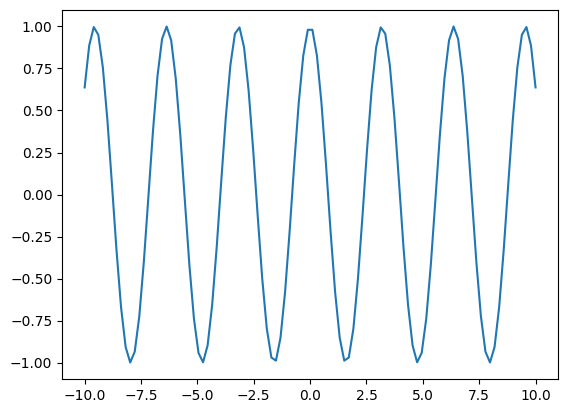

In [6]:
import quantum_toolkit as quat

k_pw = 2

dispersion=quat.Dispersion(uxgrid_dx)

wave_function = quat.plane_wave(dispersion.k2omega(k_pw), uxgrid)

plt.plot(uxgrid, np.real(wave_function['value']))


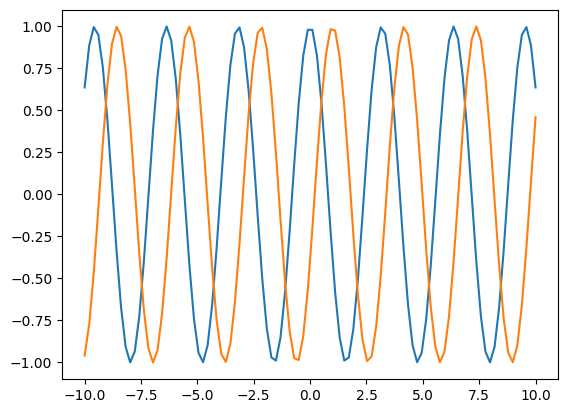

In [7]:
te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function)

plt.plot(uxgrid, np.real(te_wave_function['value'][:,0]))
plt.plot(uxgrid, np.real(te_wave_function['value'][:,10])) 

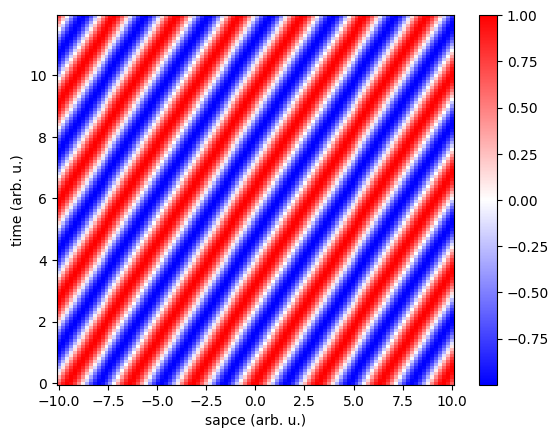

In [8]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(np.real(te_wave_function['value']))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
#plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

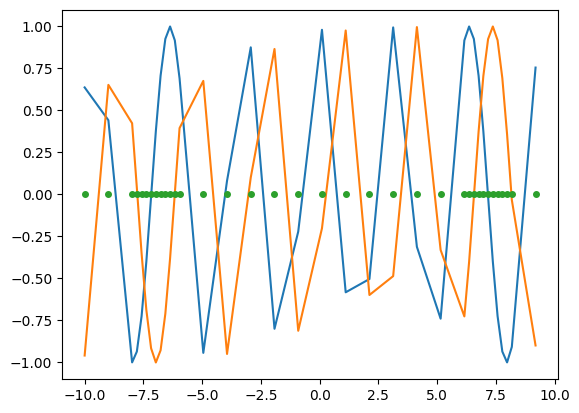

In [9]:
reduced_te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function, mask)

plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,0]))
plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,10])) 
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.show()

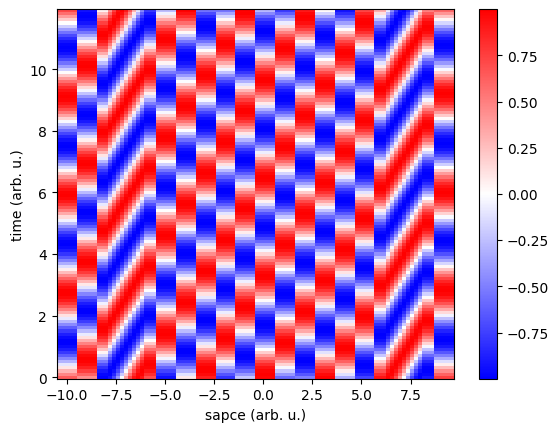

In [10]:
X,Y = np.meshgrid(reduced_uxgrid,utgrid)

Z=np.transpose(np.real(reduced_te_wave_function['value']))
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') 
plt.colorbar(pcm)
 
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.show()

# Set Atomic unit system

In [11]:
import atomic_units as au

hb=0.1
e0=10.0
m0=10.0
kappa0=1000.0 # 4*pi*epsilon0
dx=0.025

unit_sys = au.AtomicUnitSystem(hb=hb, e0=e0, me=m0, k0=kappa0)

print(unit_sys)

Unit and value of atomic base units in this rescaled atomic units:
- action unit := 	1.0545718176461564e-33 kilogram * meter ** 2 / second
- modified planck constant hbar := 	0.1
- charge unit := 	1.602176634e-20 coulomb
- elementary charge e0:= 	10.0
- mass unit := 	9.109383701500001e-32 kilogram
- electron mass me := 	10.0
- modified permittivity unit := 	1.112650055443438e-13 farad / meter
- modified permittivity kappa0 := 	1000.0

Unit and value of atomic units in this rescaled atomic units:
- length unit := 	5.291772109039772e-09 meter
- energy unit := 	4.359744722207174e-19 joule
- time unit := 	2.418884326585678e-15 second
- frequency unit := 	413413733351824.94 hertz
- velocity unit := 	2187691.263645192 meter / second
- speed of light := 	137.0359990835624
- electric field unit := 	5142206747.623186 volt / meter
- electric potential unit := 	27.211386245988493 volt



# Set unified grid

In [12]:
import numpy as np

uxgrid_num = 18*1024
uxgrid_dx = 0.025
uxgrid_width=uxgrid_num*uxgrid_dx
uxgrid = np.arange( -uxgrid_width/2 , uxgrid_width/2, uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))

<class 'numpy.ndarray'>
0.025
460.8
2438.4485878455266 nanometer


In [13]:
import quantum_toolkit as quat

dispersion=quat.Dispersion(uxgrid_dx, action = unit_sys.hbar,\
                            mass = unit_sys.me)

#Paraméter szett csak az elejére

potenciál magassága max pár eV GaN és arany vagy amit a Vaclav használt
geometriát is kb realisztikusra
potenciál gát magassága legyen 1 vagy 2 eV

Ha ez nem mutat semmit akkor periódikussat
a szélessége egy oxid réteg széles 




# Set model-potential

In [14]:

print((10 * unit_sys.ureg("bohr").to("m") / unit_sys.length_unit).magnitude)
print(unit_sys.length_unit)

0.10000000000000006
5.291772109039772e-09 meter


-3.49 electron_volt 2.72113862459885 electron_volt
-1.2825513439303358
0.9600000000000001 electron_volt 2.72113862459885 electron_volt
0.3527934928862815
2.72113862459885
0.10000000000000006
188.97261246222808


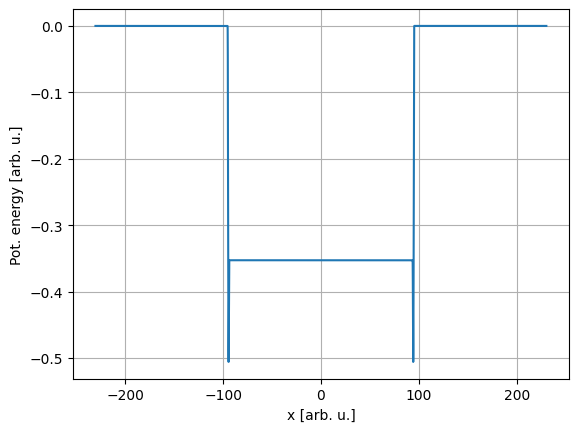

In [15]:
import matplotlib.pyplot as plt
import potentials as pots
import pint

ureg = unit_sys.ureg

#Standard electrode lists
#https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Electrochemistry_Tables/P1%3A_Standard_Reduction_Potentials_by_Element
#https://www.engineeringtoolbox.com/electrode-potential-d_482.html
#https://en.wikipedia.org/wiki/Standard_electrode_potential_(data_page)
#https://nano3dsystems.com/wp-content/uploads/2019/06/Ir.pdf
standard_potential_of_Au_in_V=1.83*ureg.volt #http://hyperphysics.phy-astr.gsu.edu/hbase/Tables/electpot.html
standard_potential_of_Al_in_V=-1.66*ureg.volt 
standard_potential_of_Ir_in_V=0.87*ureg.volt #standard_potential_of_Ir_in_V=0.87 #10.1002/elan.200403200
standard_potential_of_O3_in_V=1.246*ureg.volt # standard_potential_of_O3_in_V=1.246 #https://www.chm.uri.edu/weuler/chm112/refmater/redpottable.html

wall_in_V = standard_potential_of_Al_in_V-standard_potential_of_Au_in_V
wall_in_eV = (wall_in_V*ureg("elementary_charge").to("C")).to("eV")
wall_in_unit_sys = (wall_in_eV/unit_sys.energy_unit.to("eV")).magnitude
print(wall_in_eV,unit_sys.energy_unit.to("eV"))
print(wall_in_unit_sys)

well_in_V = standard_potential_of_Au_in_V-standard_potential_of_Ir_in_V
well_in_eV = (well_in_V*ureg("elementary_charge").to("C")).to("eV")
well_in_unit_sys = (well_in_eV/unit_sys.energy_unit.to("eV")).magnitude
print(well_in_eV,unit_sys.energy_unit.to("eV"))
print(well_in_unit_sys)

energy_unit_in_ev = unit_sys.energy_unit.to('eV').magnitude
print(energy_unit_in_ev)
length_unit_in_nm = unit_sys.length_unit.to('nm').magnitude


wall_width = (10 * unit_sys.ureg("bohr").to("m") / unit_sys.length_unit).magnitude
print(wall_width)
well_width = 1000/length_unit_in_nm
print(well_width)

modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=wall_width,\
                                   wallheight=wall_in_unit_sys,\
                                   welldepth=well_in_unit_sys,\
                                   wellwidth=well_width,\
                                   wallrise = 2,\
                                   wellfall = 2)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


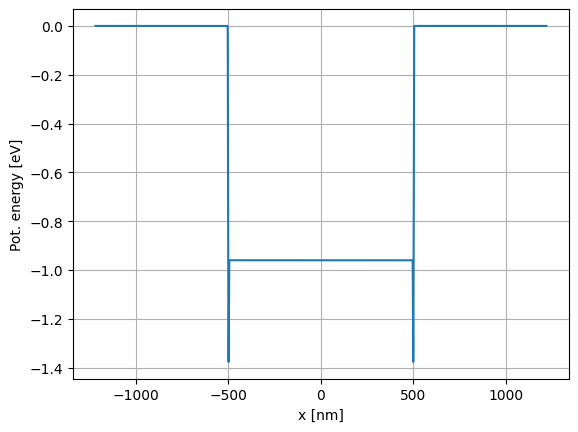

In [16]:
x = uxgrid * unit_sys.length_unit.to('nm')
y = modelpot(0) * unit_sys.energy_unit.to('eV')

plt.plot(x, y)
plt.xlabel("x [nm]")
plt.ylabel("Pot. energy [eV]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

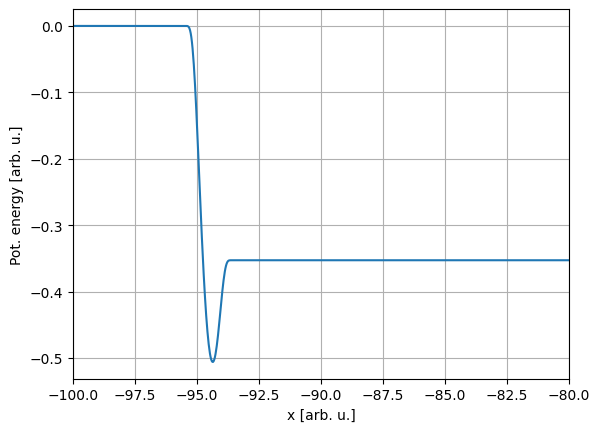

In [17]:
plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
plt.xlim([-100, -80])
plt.grid()
plt.show()

In [ ]:
# Desired number of points
desired_points = 1024

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlim([124, 128])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

In [ ]:
# Highlighted ranges
highlight_ranges = [(-122, -118), (118, 122)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

print(f"Number of uxgrid points: {uxgrid_num}")
print(f"Number of highlighted points: {highlighted_num}")

Number of uxgrid points: 16384
Number of highlighted points: 320


In [ ]:
mask += mask_highlight_ranges

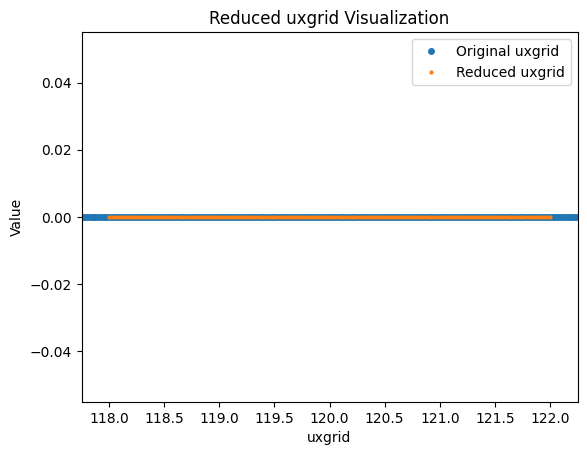

Original uxgrid length: 16384
Reduced uxgrid length: 1324


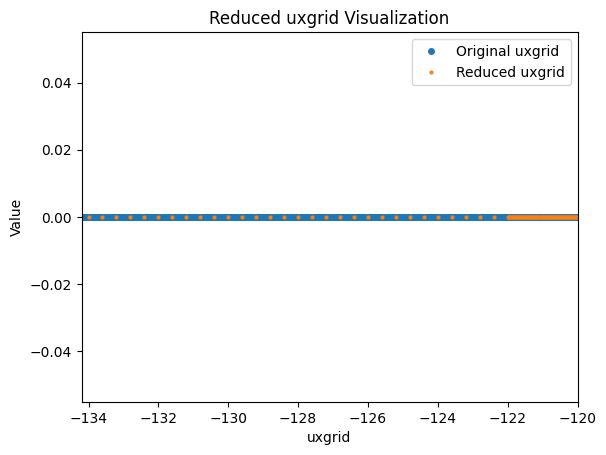

Original uxgrid length: 16384
Reduced uxgrid length: 1324


In [ ]:
# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([highlight_ranges[1][0]-10*uxgrid_dx, highlight_ranges[1][1]+10*uxgrid_dx])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([1.1*highlight_ranges[0][0], highlight_ranges[0][0]+2])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Compute eigen states

In [ ]:
#zeropot=quat.ZeroPotential(uxgrid)
zeropot=pots.ZeroPotential(uxgrid)
ham_static = quat.HamiltonOperator(uxgrid, scalarpot=modelpot, vectorpot=zeropot )

In [ ]:
import scipy.sparse as sparse

mat=ham_static(0)
eigenvalues, eigenvectors = sparse.linalg.eigsh(mat, 20,which = 'SR')

print(eigenvalues[0])

-0.3526623309092852


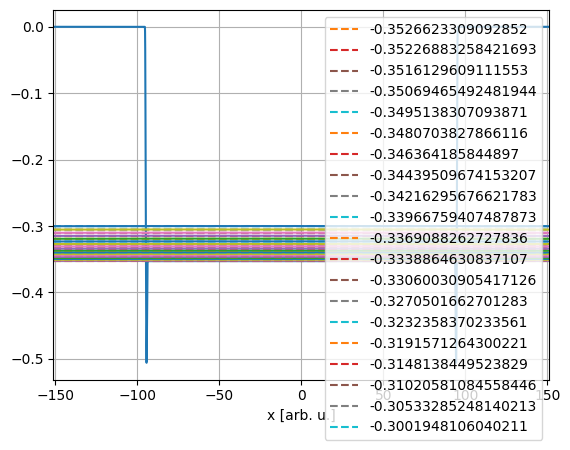

In [ ]:
# plt.plot(uxgrid,modelpot(0),label="Pot")
# plt.plot(uxgrid,np.real(eigenvectors[:,0]),label="Re")
# plt.plot(uxgrid,np.imag(eigenvectors[:,0]),label="Im")
# plt.plot(uxgrid,np.abs(eigenvectors[:,0]),label="Abs")

plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend(loc='upper right')
plt.grid()
plt.show()

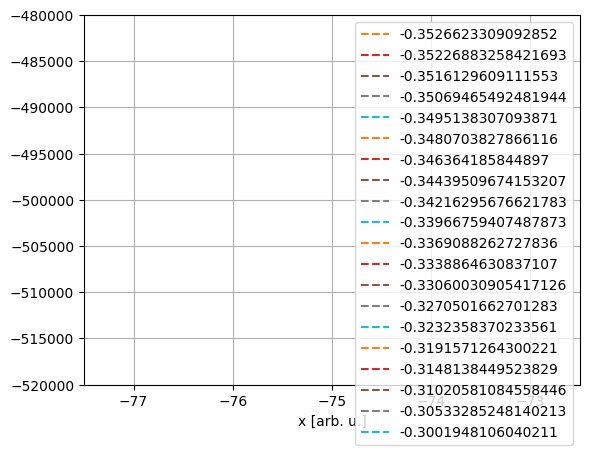

In [ ]:
plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(-520000,-480000)
plt.xlim(-77.5,-72.5)
plt.legend(loc='upper right')
plt.grid()
plt.show()

# Laser potential

In [ ]:
t_start=0
t_stop=1200.0
#t_num=10000

#utgrid=np.linspace(t_start,t_stop,t_num)
#utgrid_dt=utgrid[1]-utgrid[0]
utgrid_dt=0.1
utgrid=np.arange(t_start,t_stop,utgrid_dt)
t_num=len(utgrid)

#print(utgrid_dt)
print(t_num)

12000


In [ ]:
spot_size = (800*unit_sys.ureg("nm") / unit_sys.length_unit.to("nm")).magnitude
print(spot_size)

magnitude_of_electric_field = (1.0e6*unit_sys.ureg("V/m") / unit_sys.electric_field_unit.to("V/m")).magnitude
print(magnitude_of_electric_field)

laserpot_cep0 = pots.SmoothLaserPotential(uxgrid,\
                                    spatial_min = -0.5*spot_size,\
                                    spatial_max = 0.5*spot_size,beta=0.25)

#laserpot_cep0 = LaserPotential(uxgrid)

151.17808996978246
0.00019446903811524434


In [ ]:
# X,Y = np.meshgrid(uxgrid,utgrid)

# Z=laserpot_cep0(Y)

# z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
# pcm = plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
# plt.colorbar(pcm)
 
# plt.title('External LASER field', fontweight ="bold")
# plt.ylim(laserpot_cep0.temporal_min,1.2*laserpot_cep0.temporal_max)
# #plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
# plt.xlabel("x [arb. u.]")
# plt.ylabel("time [arb. u.]")
# plt.show()

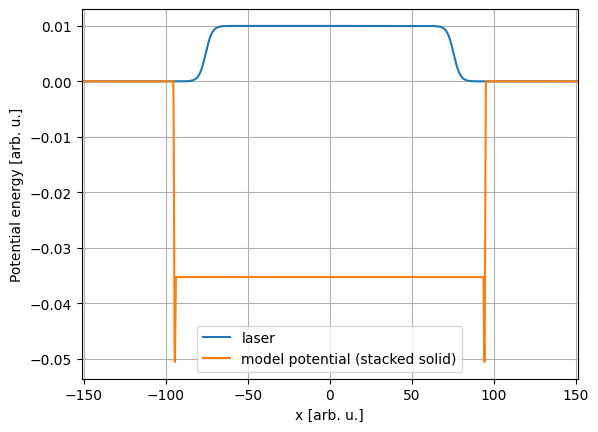

In [ ]:
plt.plot(uxgrid, laserpot_cep0(laserpot_cep0.temporal_width/2),label="laser")
plt.plot(uxgrid, 0.1*modelpot(uxgrid),label="model potential (stacked solid)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [arb. u.]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

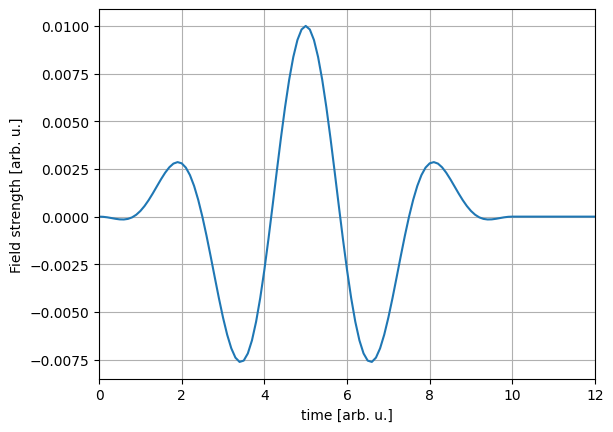

In [ ]:
plt.plot(utgrid, laserpot_cep0.value_at(0.0,utgrid),label="laser")
plt.xlabel("time [arb. u.]")
plt.ylabel("Field strength [arb. u.]")
plt.xlim(0,1.2*laserpot_cep0.temporal_width)
plt.grid()
plt.show()

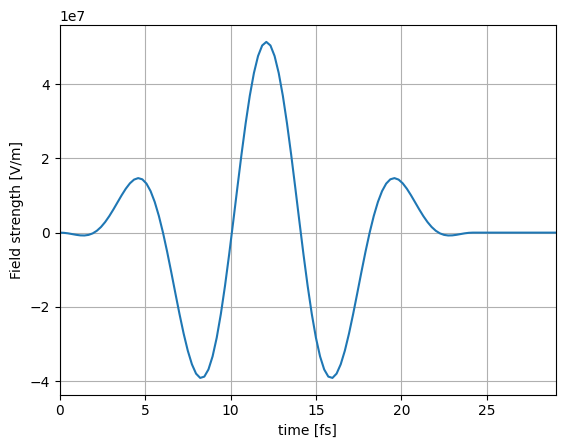

In [ ]:
x = utgrid * unit_sys.time_unit.to('fs')
y = laserpot_cep0.value_at(0.0,utgrid) * unit_sys.electric_field_unit.to('V/m')

plt.plot(x, y,label="laser")
plt.xlabel("time [fs]")
plt.ylabel("Field strength [V/m]")
plt.xlim(0,1.2*laserpot_cep0.temporal_width*unit_sys.time_unit.to('fs').magnitude)
plt.grid()
plt.show()

In [ ]:
nx=len(uxgrid)
nt=len(utgrid)

## Advanced methode

In [ ]:
import quantum_transport_toolkit as trat

ein=(1.0*unit_sys.ureg("eV") / unit_sys.energy_unit.to("eV")).magnitude #0.2
print(ein)
kin=dispersion.energy2k(ein)

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,kin,ham_static)

0.3674932217565432


In [ ]:
psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)

psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)

In [ ]:
psi_pk_te.run()

In [ ]:
psi_mk_te.run()

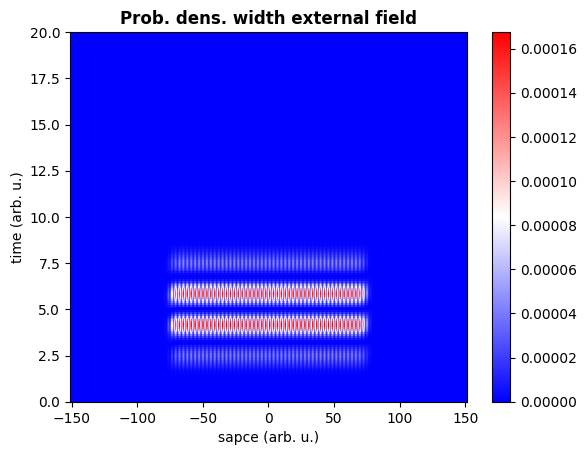

In [ ]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

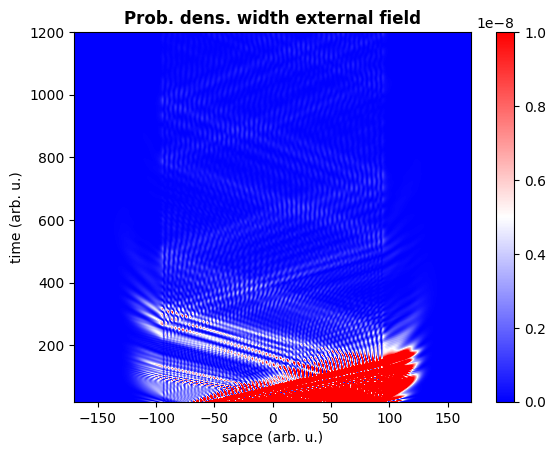

In [ ]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-8) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)
plt.show()

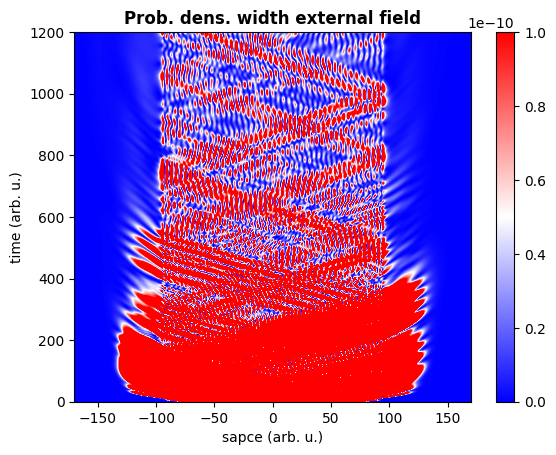

In [ ]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(0,1200)#2*laserpot_cep0.temporal_width)
plt.show()

# Compare with masked

In [ ]:
masked_psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop, mask=mask)

masked_psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop, mask=mask)

In [ ]:
masked_psi_pk_te.run()

In [ ]:
masked_psi_mk_te.run()

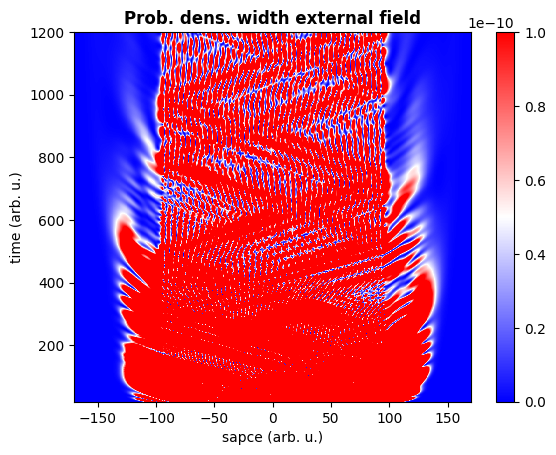

In [ ]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)
plt.show()

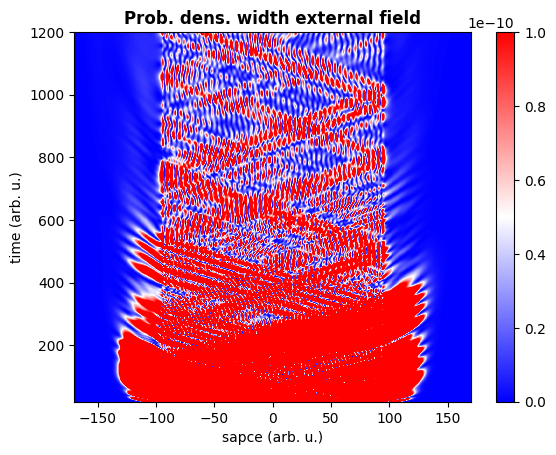

In [ ]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)#2*laserpot_cep0.temporal_width)
plt.show()

# Compute probability current

In [ ]:
# choose masurement points on the right and the left side
meas_point_right=110
meas_point_left=-meas_point_right

In [ ]:


left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(left_index,right_index)
print(x_left,x_right)

3792 12592
-109.99999999997846 110.00000000007157


In [ ]:
pc2_pk=quat.probability_current(psi_pk_te.psi_time_evolution)
pc2_mk=quat.probability_current(psi_mk_te.psi_time_evolution)

pc2_sum=pc2_pk+pc2_mk

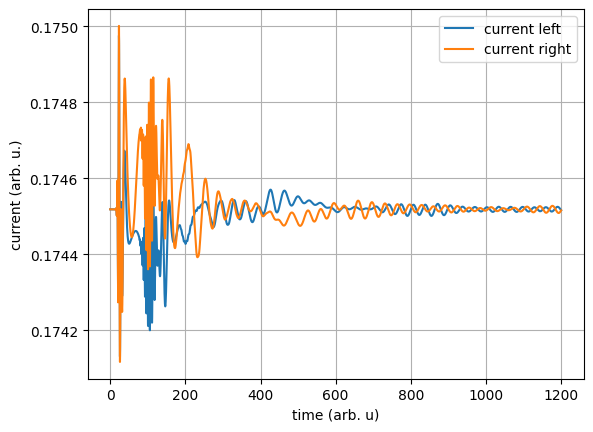

In [ ]:
pc_sum_left=pc2_sum[left_index,:]
pc_sum_right=pc2_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

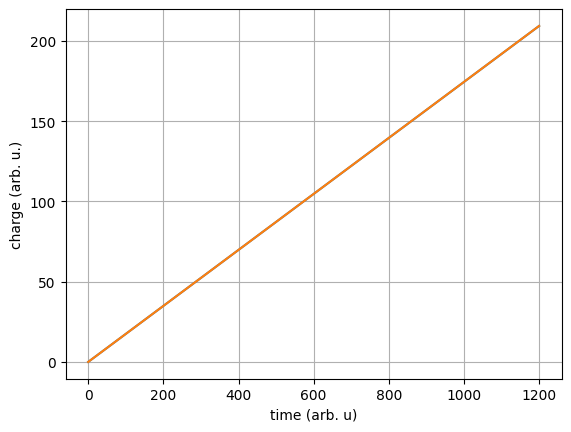

In [ ]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid, initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()

# compare with masked grid results

In [ ]:
masked_pc2_pk=quat.probability_current(masked_psi_pk_te.psi_time_evolution)
masked_pc2_mk=quat.probability_current(masked_psi_mk_te.psi_time_evolution)

masked_pc2_sum=masked_pc2_pk+masked_pc2_mk

In [ ]:
masked_left_index = np.abs(np.array(reduced_uxgrid) - meas_point_left).argmin()#1300
masked_right_index = np.abs(np.array(reduced_uxgrid) - meas_point_right).argmin()#
masked_x_left = reduced_uxgrid[masked_left_index]
masked_x_right = reduced_uxgrid[masked_right_index]

print(masked_x_left,masked_x_right)

-109.99999999997846 110.00000000007157


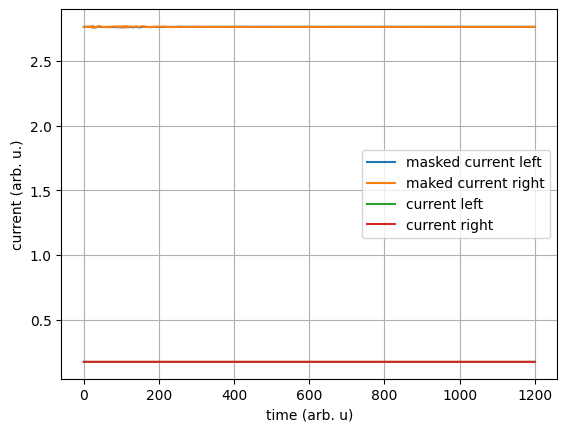

In [ ]:
masked_pc_sum_left=masked_pc2_sum[masked_left_index,:]
masked_pc_sum_right=masked_pc2_sum[masked_right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, masked_pc_sum_left,label="masked current left")
plt.plot(utgrid, masked_pc_sum_right,label="maked current right")
plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

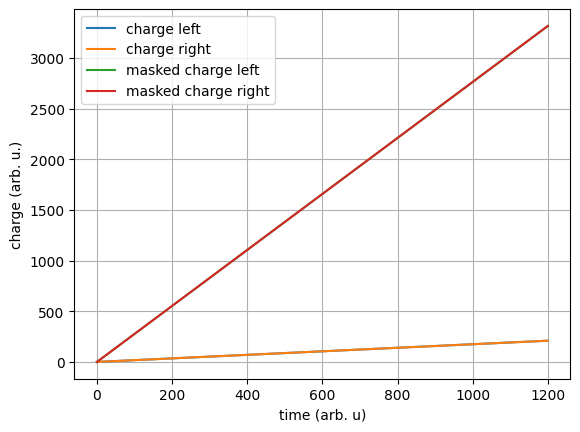

In [ ]:
from scipy import integrate

masked_charge_left = integrate.cumtrapz(masked_pc_sum_left, utgrid, initial=0)
masked_charge_right = integrate.cumtrapz(masked_pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
plt.plot(utgrid, masked_charge_left,label="masked charge left")
plt.plot(utgrid, masked_charge_right,label="masked charge right")
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.legend()
plt.grid()
plt.show()